<a href="https://colab.research.google.com/github/juanhuerta2114-png/Proyecto_final_3ersmestre_/blob/main/5_modelos_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time #Nos ayudara a tomar el tiempo para complejidad
from sklearn.model_selection import train_test_split # Para dividir datos en entrenamiento y prueba
from sklearn.preprocessing import LabelEncoder, StandardScaler # Para codificar el texto y normalizar años y ventas
from sklearn.metrics import mean_squared_error, r2_score # Para evaluar el modelo de regresión

In [ ]:
# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Carga y exploración inicial de los datos

In [ ]:
url = "https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_cat.csv"

In [ ]:
df = pd.read_csv(url)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Ventas_Cat
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,Ventas exitosas
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,Ventas exitosas
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,Ventas exitosas
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,Ventas exitosas
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,Ventas exitosas


In [ ]:
df.shape

(16598, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
 11  Ventas_Cat    16598 non-null  object 
dtypes: float64(6), int64(1), object(5)
memory usage: 1.5+ MB


# Probabilidad y Estadística (EDA y Pruebas de hipótesis)

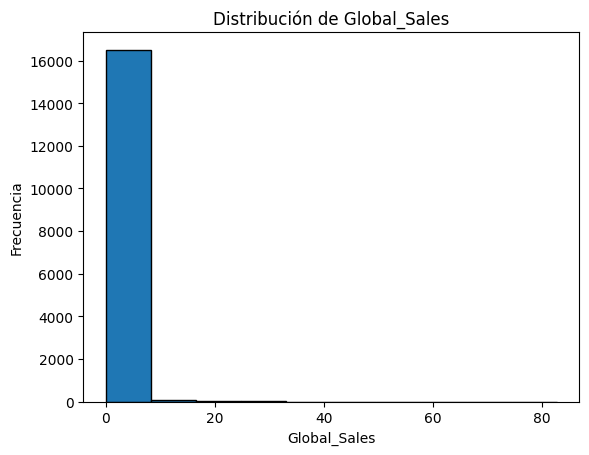

In [ ]:
# Histograma de Global_Sales
df['Global_Sales'].plot(kind='hist', bins=10, edgecolor='black')
plt.xlabel('Global_Sales')
plt.ylabel('Frecuencia')
plt.title('Distribución de Global_Sales')
plt.show()

In [ ]:
# Ventas promedio por Genre
genre_sales = df.groupby('Genre')['Global_Sales'].mean()
genre_sales = genre_sales.sort_values(ascending=False)
genre_sales


,Global_Sales
Genre,
Platform,0.938341
Shooter,0.791885
Role-Playing,0.623233
Racing,0.586101
Sports,0.567319
Fighting,0.529375
Action,0.528100
Misc,0.465762
Simulation,0.452364


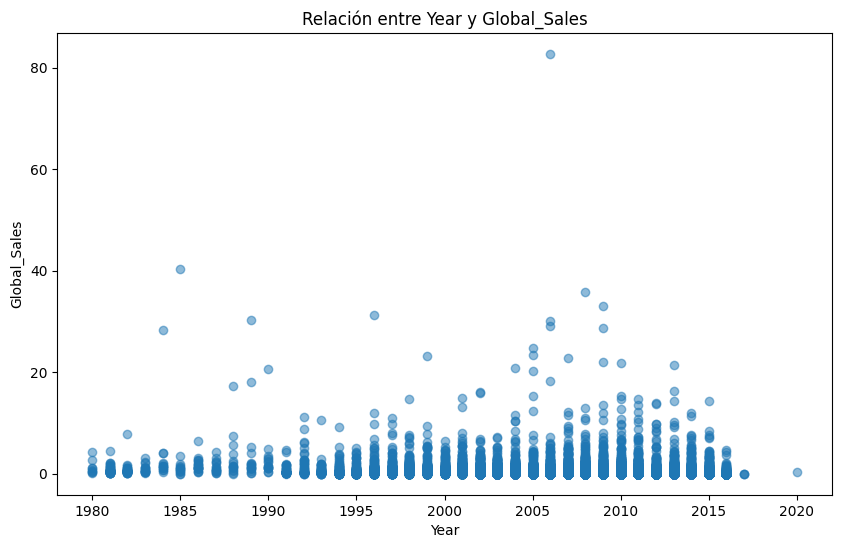

In [ ]:
# Relación Year vs Global_Sales
plt.figure(figsize=(10, 6))
plt.scatter(df['Year'], df['Global_Sales'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Global_Sales')
plt.title('Relación entre Year y Global_Sales')
plt.show()

# Limpieza de datos

In [ ]:
# Revisión de valores nulos por columna
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100

# Tabla resumen de valores nulos
missing_data = pd.DataFrame({
    'Valores nulos': null_counts,
    '% del total': null_percent.round(2)
})

display(missing_data)

,Valores nulos,% del total
Rank,0,0.00
Name,0,0.00
Platform,0,0.00
Year,271,1.63
Genre,0,0.00
Publisher,58,0.35
NA_Sales,0,0.00
EU_Sales,0,0.00
JP_Sales,0,0.00
Other_Sales,0,0.00


In [ ]:
# Mostrar los valores nulos de la columna Publisher
df[df['Publisher'].isnull()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Ventas_Cat
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00,Ventas exitosas
1303,1305,Triple Play 99,PS,NaN,Sports,NaN,0.81,0.55,0.00,0.10,1.46,Ventas intermedias
1662,1664,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,2007.0,Misc,NaN,0.87,0.32,0.00,0.02,1.21,Ventas intermedias
2222,2224,Bentley's Hackpack,GBA,2005.0,Misc,NaN,0.67,0.25,0.00,0.02,0.93,Ventas intermedias
3159,3161,Nicktoons Collection: Game Boy Advance Video V...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.01,0.64,Ventas intermedias
3166,3168,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.01,0.64,Ventas intermedias
3766,3768,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.38,0.14,0.00,0.01,0.53,Ventas intermedias
4145,4147,Sonic the Hedgehog,PS3,NaN,Platform,NaN,0.00,0.48,0.00,0.00,0.48,Ventas bajas
4526,4528,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.31,0.11,0.00,0.01,0.43,Ventas bajas
4635,4637,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.30,0.11,0.00,0.01,0.42,Ventas bajas


In [ ]:
# Mostrar los valores nulos de la columna Year
df[df['Year'].isnull()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Ventas_Cat
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23,Ventas exitosas
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49,Ventas exitosas
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17,Ventas exitosas
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00,Ventas exitosas
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53,Ventas exitosas
...,...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01,Ventas bajas
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01,Ventas bajas
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01,Ventas bajas
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01,Ventas bajas


Basándonos en los resultados anteriores, tomamos las siguientes decisiones:
- `Publisher`: Dado que tenemos valores nulos en clases de Ventas altas y Ventas intermedias, no se eliminan. Se imputan como "Unknown" para mantener la integridad de los datos.

- `Year`: Hay 10 valores nulos en `Ventas exitosas` y 43 en `Ventas intermedias`, por lo que optamos por rellenar esos datos buscando los datos reales de los juegos en internet (curación de datos). No los eliminamos porque si un juego es un "éxito" pero no tiene año, le estamos quitando al modelo la oportunidad de entender la tendencia del mercado en esa época. Para los valores nulos de de `Ventas bajas` decidimos rellenar usando la mediana por Plataforma.

In [ ]:
# Dataset con los valores nulos rellenados, faltan algunos en Year
df_vgsales = pd.read_csv("https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_clean.csv")

In [ ]:
# Rellenamos los valores faltantes de Year usando la mediana de su propia plataforma
df_vgsales['Year'] = df_vgsales['Year'].fillna(df_vgsales.groupby('Platform')['Year'].transform('median'))

In [ ]:
df_vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Ventas_Cat
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,Ventas exitosas
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,Ventas exitosas
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,Ventas exitosas
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,Ventas exitosas
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,Ventas exitosas


Revisamos otra vez los valores nulos

In [ ]:
# Revisión de valores nulos por columna
null_counts = df_vgsales.isnull().sum()
null_percent = (null_counts / len(df_vgsales)) * 100

# Tabla resumen de valores nulos
missing_data = pd.DataFrame({
    'Valores nulos': null_counts,
    '% del total': null_percent.round(2)
})

display(missing_data)

,Valores nulos,% del total
Rank,0,0.0
Name,0,0.0
Platform,0,0.0
Year,0,0.0
Genre,0,0.0
Publisher,0,0.0
NA_Sales,0,0.0
EU_Sales,0,0.0
JP_Sales,0,0.0
Other_Sales,0,0.0


A continuación, descartamos las columnas que no sirven para el aprendizaje

In [ ]:
df_clean = df_vgsales.drop(columns=['Rank', 'Name', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'])
df_clean.head()

,Platform,Year,Genre,Publisher,Ventas_Cat
0,Wii,2006.0,Sports,Nintendo,Ventas exitosas
1,NES,1985.0,Platform,Nintendo,Ventas exitosas
2,Wii,2008.0,Racing,Nintendo,Ventas exitosas
3,Wii,2009.0,Sports,Nintendo,Ventas exitosas
4,GB,1996.0,Role-Playing,Nintendo,Ventas exitosas


Aquí estamos eliminando las columnas de NA_Sales, EU_Sales, JP_Sales, Other_Sales y Global_Sales porque permitirían predecir directamente al modelo si un juego es exitoso o no, es decir que haría "trampa" el modelo. Lo mismo pasa con Rank. También, eliminamos la columna Name porque es texto (los modelos no leen texto).

# Preparación de datos

### Codificación de variables categóricas

In [ ]:
# Ajuste de Publisher
top_publishers = df_clean['Publisher'].value_counts().nlargest(10).index
df_clean['Publisher'] = df_clean['Publisher'].apply(lambda x: x if x in top_publishers else 'Other')

In [ ]:
top_publishers

Index(['Electronic Arts', 'Activision', 'Namco Bandai Games', 'Ubisoft',
       'Konami Digital Entertainment', 'THQ', 'Nintendo',
       'Sony Computer Entertainment', 'Sega', 'Take-Two Interactive'],
      dtype='object', name='Publisher')

Reducimos la cardinalidad de la variable Publisher agrupando las categorías que menos aparecian en 'Other', con el fin de evitar una alta dimensionalidad y mejorar el rendimiento en los modelos de KNN y regresión.

In [ ]:
# Usamos get_dummies para Genre, Platform y Publisher ajustado, con dtype=int para que sean de tipo 1/0
df_clean = pd.get_dummies(df_clean, columns=['Genre', 'Platform', 'Publisher'], dtype=int)

# Convertimos Ventas_Cat (target) a numérico con el mapeo deseado
mapping = {
    'Ventas exitosas': 2,
    'Ventas intermedias': 1,
    'Ventas bajas': 0
}
df_clean['Ventas_Cat'] = df_clean['Ventas_Cat'].replace(mapping)

df_clean.head()

/tmp/ipykernel_25428/1970230537.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Ventas_Cat'] = df_clean['Ventas_Cat'].replace(mapping)


,Year,Ventas_Cat,Genre_Action,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,...,Publisher_Electronic Arts,Publisher_Konami Digital Entertainment,Publisher_Namco Bandai Games,Publisher_Nintendo,Publisher_Other,Publisher_Sega,Publisher_Sony Computer Entertainment,Publisher_THQ,Publisher_Take-Two Interactive,Publisher_Ubisoft
0,2006.0,2,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,1985.0,2,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2008.0,2,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,2009.0,2,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,1996.0,2,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
df_clean.shape

(16598, 56)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Cargar el dataset desde tu GitHub
url = "https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_cat.csv"
df = pd.read_csv(url)

# Imprimir las columnas para que las veas en tu pantalla
print("=== Columnas detectadas en tu archivo ===")
print(df.columns.tolist())
print("-" * 50)

# =====================================================================
# CONFIGURACIÓN MANUAL: Ajusta estos nombres según tu proyecto
# =====================================================================
columna_objetivo = 'Ventas_Cat'

# Lista de columnas de texto o IDs que NO aportan al modelo matemáticamente (ej. Nombre del juego, Rank)
# Agrega aquí las que correspondan si te llega a dar error de tipo 'string'
columnas_a_eliminar = [
    columna_objetivo,
    'Name',
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales'
]
# =====================================================================

# Limpieza rápida: Eliminar filas con valores vacíos para evitar errores
df = df.dropna()

# Separar en características (X) y etiqueta (y)
y_proyecto = df[columna_objetivo]
X_proyecto = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])

# Convertimos Ventas_Cat (target) a numérico con el mapeo deseado
mapping = {
    'Ventas exitosas': 2,
    'Ventas intermedias': 1,
    'Ventas bajas': 0
}
y_proyecto = y_proyecto.replace(mapping)

# Si quedan columnas categóricas (texto), las convertimos a números automáticamente (One-Hot Encoding)
X_proyecto = pd.get_dummies(X_proyecto, drop_first=True)

# División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_proyecto, y_proyecto, test_size=0.2, random_state=42)

print(f"¡Datos cargados con éxito!")
print(f"Muestras de entrenamiento: {X_train.shape[0]} | Características numéricas: {X_proyecto.shape[1]}")

=== Columnas detectadas en tu archivo ===
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Ventas_Cat']
--------------------------------------------------
¡Datos cargados con éxito!
Muestras de entrenamiento: 13032 | Características numéricas: 618


/tmp/ipykernel_25428/2054324616.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_proyecto = y_proyecto.replace(mapping)


# Matematica Aplicadas a la Ciencias de los Datos

El objetivo de este apartado del Notebook es explorar y aplicar los algoritmos del aprendizaje supervisado, integrando los pilares de las matematicas aplicadas (álgebra lineal, cálculo y estadistica).

Ademas analizaremos su comportamiento interno mediante el estudio de sus funciones de pérdida y mecanismos de optimización.

## 1. Modelado Algorítmico
Implementaremos una variedad de arquitecturas según la naturaleza del dato:



*   Modelos Lineales: Regresión Lineal para variables continuas y Regresión Logística para clasificación binaria.
*   Modelos Basados en Distancia: K-Nearest Neighbors (KNN) para entender la proximidad de datos en espacios n-dimensionales.
*   Modelos Basados en Árboles: Desde la lógica simple de un Árbol de Decisión y ensambles con Random Forest.

## Evaluacion y Compresión
Evaluaremos:
* Métricas de Error: MAE, MSE Y R^2, para regresión. Matriz de Confusión y F1-Score para clasificación.
* Interpretabilidad: Análisis de modelos para interpretar las decisiones que toman los algoritmos.

## Optimización
Profundizameros en el Descenso del Gradiente, la técnica de cálculo multivarado que permite minimizar la función de coste.




## Implementacion Matematica de **Regresión Logistica**

Modelo de ML para clasificación, cuando la variable objetivo es categórica, es decir toma, valores discretos (e.g., si/no, spam/no spam) para nuestro caso exito vs fracaso.

En este notebook vamos a aplicar el modelo **regresion logistica** al dataset de un listado de **Ventas de Videojuegos** que han superado las 100,000 copias.

Algunas caracteristicas del data set:
* Mas de 16,500 juegos.
* Variables:
  * Identificadores: Nombre del Juego, Plataforma(Wii, NES, PS4, etc). Año de lanzamiento y Género (Acción, Deportes, Shooter, etc).
  * Ventas Geograficas: Ventas en Norteamérica (NA_Sales), Europa(EU_Sales), Japón(JP_Sales) y otros lugares.
  * Ventas Globales: La suma total de ventas en millones de unidades (Global_Sales).

En un problema de clasificación binaria. el objetivo es predicir si un objetivo pertenece a una de dos clases, posibles

$y \in \{0,1\}$

Que en nuestro caso nos servira para predecir si un juego será un "exito" (ventas altas) basándonos en su género, plataforma o región.


### 1. Análisis exploratorio y limpieza de datos.
En esta fase, transformamos los datos en bruto del CSV en un formato que las funciones matemáticas puedan procesar.Variable Objetivo ($y$): Creamos una clasificación binaria donde un "1" representa un éxito comercial (ventas $> 1$ millón).Variables Predictoras ($X$): Convertimos variables categóricas (como el Género) en números mediante One-Hot Encoding (Dummies). Esto es vital porque los modelos de regresión solo entienden matrices numéricas.

Antes de entrenar, aplicamos estadística descriptiva. Las tablas de contingencia nos permiten observar la probabilidad a priori. Por ejemplo, si vemos que el 20% de los juegos de "Shooter" son exitosos vs. solo el 3% de "Adventure", ya sabemos de antemano qué variables tendrán un coeficiente $\beta$ más alto y positivo.

In [ ]:
### 1. Análisis exploratorio y limpieza de datos.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score

url = "https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_cat.csv"
df_RL = pd.read_csv(url)
df_RL.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Ventas_Cat
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,Ventas exitosas
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,Ventas exitosas
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,Ventas exitosas
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,Ventas exitosas
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,Ventas exitosas


In [ ]:
df_RL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
 11  Ventas_Cat    16598 non-null  object 
dtypes: float64(6), int64(1), object(5)
memory usage: 1.5+ MB


In [ ]:
df['y'] = (df['Global_Sales'] > 1.0).astype(int)
# Variables categóricas para análisis
cat_cols = ['Platform', 'Genre']

# Generar tablas de contingencia para ver probabilidades de éxito
for col in cat_cols:
    display(pd.crosstab(df[col], df['y'], normalize='index')
            .style.format("{:.1%}")
            .set_caption(f"Distribución de éxito según {col}"))

y,0,1
Platform,,
2600,80.2%,19.8%
3DO,100.0%,0.0%
3DS,90.6%,9.4%
DC,88.5%,11.5%
DS,93.3%,6.7%
GB,45.4%,54.6%
GBA,91.3%,8.7%
GC,91.5%,8.5%
GEN,59.3%,40.7%


y,0,1
Genre,,
Action,87.2%,12.8%
Adventure,96.9%,3.1%
Fighting,85.5%,14.5%
Misc,90.3%,9.7%
Platform,77.8%,22.2%
Puzzle,90.4%,9.6%
Racing,85.5%,14.5%
Role-Playing,86.3%,13.7%
Shooter,80.9%,19.1%


/tmp/ipykernel_25428/186324502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='viridis')


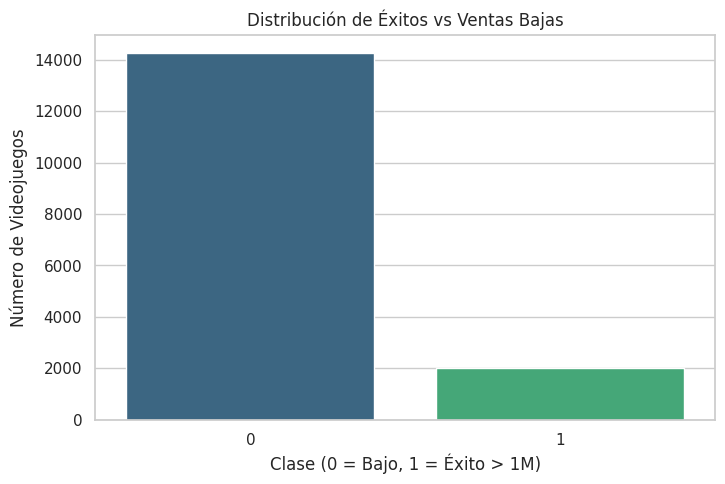

/tmp/ipykernel_25428/186324502.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_success.index, y=genre_success.values, palette='magma')


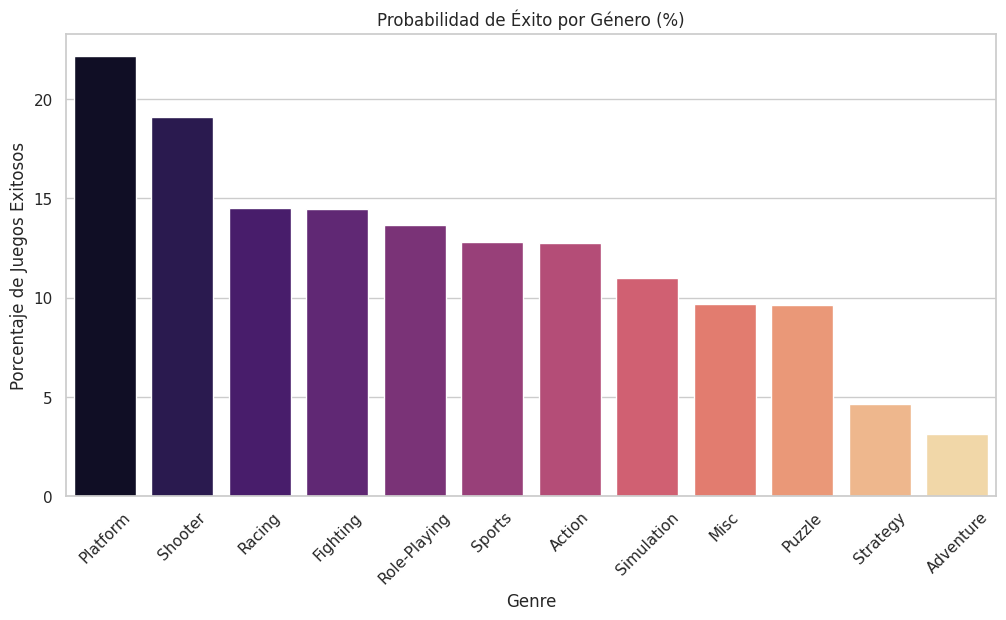

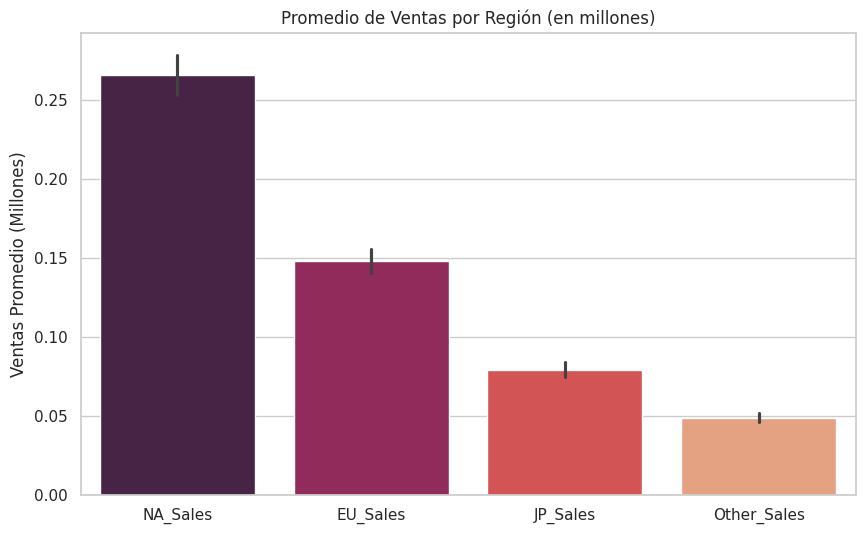

/tmp/ipykernel_25428/186324502.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_success.index, y=platform_success.values, palette='viridis')


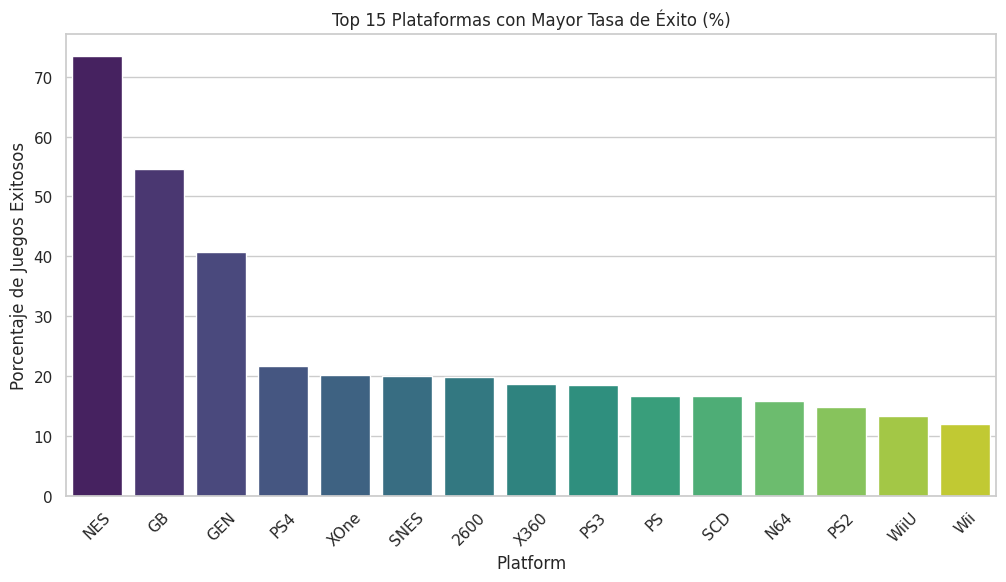

In [ ]:

# Configuración de estilo
sns.set(style="whitegrid")

# 1. Distribución de Éxitos (Variable Objetivo 'y')
plt.figure(figsize=(8, 5))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribución de Éxitos vs Ventas Bajas')
plt.xlabel('Clase (0 = Bajo, 1 = Éxito > 1M)')
plt.ylabel('Número de Videojuegos')
plt.show()

# 2. Tasa de Éxito por Género
# Calculamos el promedio de 'y' por género y lo convertimos a porcentaje
genre_success = df.groupby('Genre')['y'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_success.index, y=genre_success.values, palette='magma')
plt.title('Probabilidad de Éxito por Género (%)')
plt.ylabel('Porcentaje de Juegos Exitosos')
plt.xticks(rotation=45)
plt.show()

# 3. Comparativa de Ventas Promedio por Región
regiones = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
plt.figure(figsize=(10, 6))
sns.barplot(data=df[regiones], palette='rocket')
plt.title('Promedio de Ventas por Región (en millones)')
plt.ylabel('Ventas Promedio (Millones)')
plt.show()

# 4. Top 15 Plataformas con mayor tasa de Éxito
platform_success = df.groupby('Platform')['y'].mean().sort_values(ascending=False).head(15) * 100
plt.figure(figsize=(12, 6))
sns.barplot(x=platform_success.index, y=platform_success.values, palette='viridis')
plt.title('Top 15 Plataformas con Mayor Tasa de Éxito (%)')
plt.ylabel('Porcentaje de Juegos Exitosos')
plt.xticks(rotation=45)
plt.show()

### 2 Implementación Manual de la Regresión Logística



In [ ]:
def logitprobs(X, beta):
    # Calcula la probabilidad pi usando la función sigmoide
    n_rows = np.shape(X)[0]
    n_cols = np.shape(X)[1]
    pi = np.zeros(n_rows)
    expon = X @ beta # Producto punto matriz-vector
    pi = 1 / (1 + np.exp(-expon))
    return pi

def findW(pi):
    # Crea la matriz diagonal de pesos para el método de Newton
    n = len(pi)
    W = np.diag(pi * (1 - pi))
    return W

def logistics(X, Y, limit):
    # Algoritmo de Newton-Raphson para encontrar los betas óptimos
    nrow = np.shape(X)[0]
    bias = np.ones((nrow, 1))
    X_new = np.hstack((X, bias))
    ncol = X_new.shape[1]
    beta = np.zeros((ncol, 1))

    iter_i = 1000
    while(iter_i > limit):
        pi = logitprobs(X_new, beta).reshape(-1, 1)
        W = findW(pi.flatten())

        # Gradiente y Hessiano (Álgebra Lineal)
        num = X_new.T @ (Y - pi)
        den = X_new.T @ W @ X_new

        root_dif = np.linalg.inv(den) @ num
        beta = beta + root_dif
        iter_i = np.sum(root_dif**2)

    return beta

### 3 Selección de Variables (RFE) y Prevención de Data Leakage

Antes de entrenar el modelo, es útil preguntarnos:  
> ¿Todas las variables realmente aportan información relevante?  
> ¿Podemos eliminar algunas sin perder rendimiento?

El método **RFE (Recursive Feature Elimination)** es una técnica de selección de variables que **elimina recursivamente** las menos importantes según un modelo base (como la regresión logística), hasta quedarse con un subconjunto óptimo.

El proceso funciona así:
1. Entrena un modelo sobre el conjunto completo de variables.
2. Calcula la importancia de cada variable (por ejemplo, mediante coeficientes absolutos).
3. Elimina la variable menos importante.
4. Repite hasta alcanzar el número deseado de variables.

Este método ayuda a:
- Reducir la complejidad del modelo.
- Mejorar la interpretabilidad.
- Evitar el sobreajuste cuando hay muchas variables irrelevantes.

A continuación, aplicaremos RFE con regresión logística como modelo base para seleccionar las variables más relevantes antes de entrenar el modelo final.

In [ ]:
# 1. Crear matriz X con variables que el modelo DEBE predecir (Género y Plataforma)
X_categorical = pd.get_dummies(df[['Genre', 'Platform']], drop_first=True)
X = X_categorical.astype(float)
y = df['y']


# 2. RFE para seleccionar las 12 mejores variables predictoras
n_features = 12
rfe = RFE(estimator=LogisticRegression(max_iter=20000), n_features_to_select=n_features)
rfe.fit(X, y)

# Filtrar X con las columnas seleccionadas
X_rfe = X[X.columns[rfe.support_]]
print("Variables seleccionadas:", list(X_rfe.columns))

Variables seleccionadas: ['Genre_Adventure', 'Genre_Strategy', 'Platform_DS', 'Platform_GB', 'Platform_GC', 'Platform_GEN', 'Platform_NES', 'Platform_PC', 'Platform_PSP', 'Platform_PSV', 'Platform_SAT', 'Platform_XB']


### 4 Entrenamiento y Validación Comparativa

Dividimos el dataset en Entrenamiento (para aprender) y Prueba (para evaluar). Usamos una división estratificada para asegurar que, aunque los juegos exitosos sean pocos, estén bien representados en ambos grupos para que la evaluación sea justa.

In [ ]:
# Split Estratificado
X_train, X_test, X_rfe_train, X_rfe_test, y_train, y_test = train_test_split(
    X, X_rfe, y, test_size=0.3, random_state=42, stratify=y
)

# Entrenar modelos de Scikit-Learn
lr_completo = LogisticRegression(max_iter=20000).fit(X_train, y_train)
lr_rfe = LogisticRegression(max_iter=20000).fit(X_rfe_train, y_train)

# Comparar exactitud
print(f"Exactitud (Total): {accuracy_score(y_test, lr_completo.predict(X_test)):.4f}")
print(f"Exactitud (RFE): {accuracy_score(y_test, lr_rfe.predict(X_rfe_test)):.4f}")

Exactitud (Total): 0.8785
Exactitud (RFE): 0.8781


### 5 Evaluación Final
Usamos herramientas de diagnóstico como la Matriz de Confusión y el Reporte de Clasificación. Aquí validamos si el modelo es útil en el mundo real revisando qué tan bien equilibra la precisión (no dar falsas alarmas) con la sensibilidad (encontrar los éxitos reales).

--- Reporte de Clasificación (Modelo RFE) ---
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      4279
           1       0.71      0.04      0.07       609

    accuracy                           0.88      4888
   macro avg       0.79      0.52      0.50      4888
weighted avg       0.86      0.88      0.83      4888



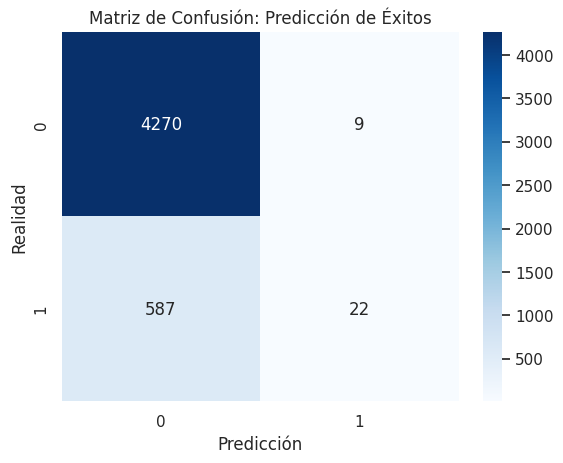

In [ ]:
y_pred_rfe = lr_rfe.predict(X_rfe_test)

print("--- Reporte de Clasificación (Modelo RFE) ---")
print(classification_report(y_test, y_pred_rfe))

# Visualizar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_rfe)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Predicción de Éxitos')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

## Implementacion Matematica **Arboles de Decisión para clasificación**

Los Árboles de Decisión son modelos de aprendizaje supervisado que, a diferencia de la regresión logística (que utiliza funciones continuas), operan mediante una lógica de partición recursiva del espacio. En el contexto de nuestro dataset, el árbol actúa como un sistema de reglas secuenciales que busca predecir si un título superará el millón de copias vendidas basándose en variables categóricas y numéricas.

1. Mecánica de Decisión:En lugar de calcular coeficientes $\beta$, el árbol formula preguntas binarias sobre las características del juego. Por ejemplo, el nodo raíz podría preguntar: "¿El género es 'Shooter'?". Si la respuesta es afirmativa, el modelo evalúa una segunda característica, como: "¿La plataforma es 'PS4'?".

El objetivo es descender a través de las "ramas" hasta llegar a las hojas (nodos terminales), donde se asigna una etiqueta de clase: Éxito (1) o Venta Baja (0).

2. Medidas de Impureza: El Criterio Matemático
Para que el árbol sea eficiente, debe elegir la pregunta que mejor separe los éxitos de los fracasos. Para cuantificar qué tan "mezclado" está un grupo de datos, utilizamos medidas de impureza.


### Medidas de impureza: Gini y Entropía

Dos de las medidas más comunes para cuantificar la impureza en clasificación son el **índice de Gini** y la **entropía**.

- **Índice de Gini**: mide la probabilidad de clasificar incorrectamente un elemento si se asigna aleatoriamente según la distribución de clases en ese nodo. Un nodo con Gini = 0 significa que es "puro": todos los juegos en ese nodo son exitosos o todos son ventas bajas. Se calcula como:

\begin{equation}
G = 1 - \sum_{k=1}^{K} p_k^2
\end{equation}

donde $p_k$ es la proporción de ejemplos de la clase $k$ en el nodo. Un nodo es puro cuando $G = 0$.

- **Entropía**: Basada en la teoría de la información, la entropía mide el desorden o la incertidumbre. Un nodo con clases equilibradas (50% éxito, 50% fracaso) tiene la entropía máxima. Es un poco más sensible a clases menos frecuentes. Se calcula como:

\begin{equation}
H = - \sum_{k=1}^{K} p_k \log_2(p_k)
\end{equation}

En ambos casos, el valor es mínimo cuando el nodo es puro (todas las observaciones pertenecen a una sola clase) y máximo cuando las clases están balanceadas. Durante el entrenamiento, el algoritmo evalúa todas las posibles divisiones y elige aquella que **maximiza la ganancia de información** o **reduce más la impureza total**.

### ¿Por qué usar árboles?

Los árboles son ideales para este dataset porque:

Capturan interacciones no lineales: Un género puede ser exitoso solo en una consola específica.

Interpretabilidad: Permiten visualizar el "camino al éxito" de un juego de manera gráfica.

Sin embargo, para evitar el sobreajuste (overfitting) —donde el árbol memoriza los datos en lugar de aprender patrones—, aplicamos técnicas de poda previa ajustando hiperparámetros como la profundidad máxima (max_depth) y el mínimo de muestras por hoja (min_samples_leaf).

### 1 Importación de librerías y carga de dato

In [ ]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import KFold, cross_val_score

# Graphviz para visualizar el árbol
from graphviz import Source

url = "https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_cat.csv"
df_AD = pd.read_csv(url)

### 2 Instanciación con Hiperparámetros de Control

In [ ]:
# 1. Definimos las variables que SÍ queremos (categóricas y numéricas)
columnas_interes = ['Genre', 'Platform', 'Year']

# 2. Convertimos a dummies solo las columnas necesarias
X = pd.get_dummies(df_AD[columnas_interes], drop_first=True).astype(float)

# 3. La variable objetivo (y) se mantiene igual
y = (df_AD['Global_Sales'] > 1.0).astype(int)


# 4. Ahora sí, hacemos el split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
# 5. Definimos el modelo buscando un equilibrio (poda previa)
modelo_vgsales = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,           # Evita que el árbol crezca infinito
    min_samples_leaf=10,    # Asegura que cada regla sea estadísticamente relevante
    random_state=42,
    class_weight='balanced'
)

# 6. Entrenamiento
modelo_vgsales.fit(X_train, y_train)
print("¡Entrenamiento exitoso!")
print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")

¡Entrenamiento exitoso!
Entrenamiento: 11618 registros
Prueba: 4980 registros


### 3 Evaluación mediante Matriz de Confusion


--- Reporte de Clasificación (Video Game Success) ---
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      4364
           1       0.19      0.26      0.22       616

    accuracy                           0.77      4980
   macro avg       0.54      0.55      0.54      4980
weighted avg       0.80      0.77      0.78      4980



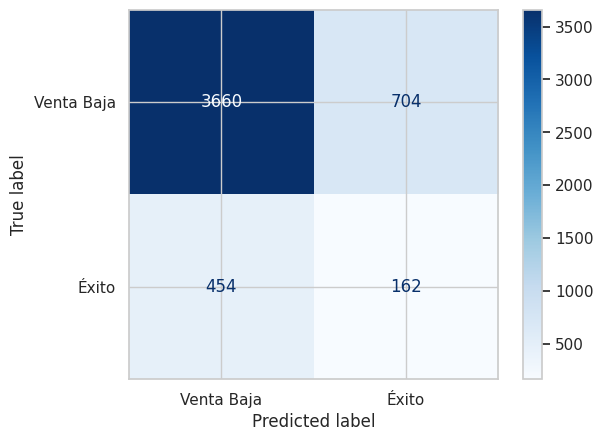

In [ ]:
y_pred = modelo_vgsales.predict(X_test)

print("--- Reporte de Clasificación (Video Game Success) ---")
print(classification_report(y_test, y_pred))

# Visualización de la matriz
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Venta Baja', 'Éxito']).plot(cmap='Blues')

### 4 Visualización de la Lógica del Árbol

Área Bajo la Curva (AUC-Score): 0.6033


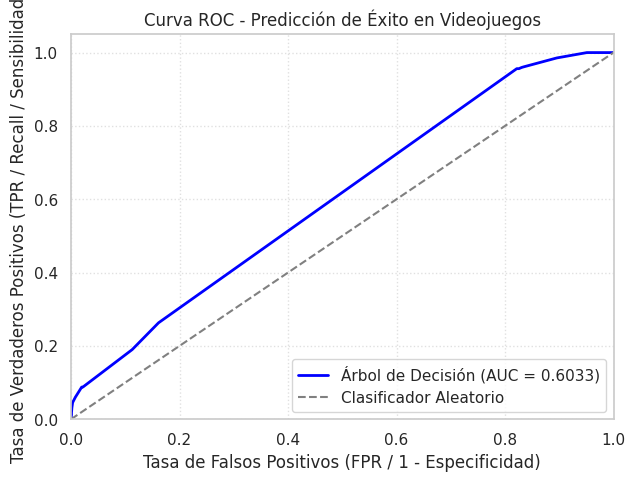

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Obtenemos las probabilidades de la clase positiva (Éxito = 1)
# predict_proba nos da dos columnas: [prob_clase_0, prob_clase_1]. Nos quedamos con la segunda [:, 1]
y_probidades = modelo_vgsales.predict_proba(X_test)[:, 1]

# 2. Calculamos el valor numérico del AUC (Área Bajo la Curva)
auc_value = roc_auc_score(y_test, y_probidades)
print(f"Área Bajo la Curva (AUC-Score): {auc_value:.4f}")

# 3. Calculamos los componentes de la curva ROC: Falsos Positivos (FPR) y Verdaderos Positivos (TPR)
fpr, tpr, umbrales = roc_curve(y_test, y_probidades)

# 4. Graficamos la curva ROC utilizando matplotlib
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Árbol de Decisión (AUC = {auc_value:.4f})')

# Dibujamos la línea diagonal discontinua (el modelo aleatorio o "azar")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador Aleatorio')

# Configuraciones de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR / 1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall / Sensibilidad)')
plt.title('Curva ROC - Predicción de Éxito en Videojuegos')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

# Mostrar la gráfica
plt.show()

In [ ]:
from IPython.display import HTML, display
from sklearn.tree import export_graphviz
from graphviz import Source

# Assuming 'modelo_vgsales' and 'X' are available from previous cells (e.g., ZDkNcr5uCOHa)
dot_data = export_graphviz(
    modelo_vgsales,
    out_file=None,
    feature_names=X.columns, # Using X.columns from the data preparation in ZDkNcr5uCOHa
    class_names=['Venta Baja', 'Éxito'], # Based on class labels used in evaluation (sqMPtatqIfgw)
    filled=True,
    rounded=True,
    special_characters=True
)
grafico_horizontal = Source(dot_data)

svg_data = grafico_horizontal.pipe(format='svg')

html_scroll = f"""
<div style="width: 100%; overflow-x: auto; overflow-y: hidden; white-space: nowrap; border: 1px solid #ddd; padding: 10px;">
    {svg_data.decode('utf-8')}
</div>
"""

display(HTML(html_scroll))

In [ ]:
# Guarda el árbol como un archivo PDF en tu entorno de trabajo
grafico_horizontal.render("arbol_completo_videojuegos", format="pdf", cleanup=True)

# O si lo prefieres en una imagen PNG de alta resolución para tus diapositivas:
grafico_horizontal.render("arbol_completo_videojuegos", format="png", cleanup=True)

print("¡Archivos guardados exitosamente en tu carpeta del notebook!")

¡Archivos guardados exitosamente en tu carpeta del notebook!


### Conclusión
Aqui los resultados de nuestro modelo de Arboles de Desición vimos como el modelo se enfoca en diminuir la entropia y al hacerlo nos unas conclusiones llamativas de como el modelo hace una particion en los video juegos que son antes del año **2000** los que vienen despues, tambien no da una idea de como algunos videos son un exito segun su genero y plataforma. Y los resultado son modestos **77%** de exactitud y un AUC de **0.603** esto se puede mejorar cambiando algunos parametros del modelo para que mejor funcione entre ellos el variar el umbral del ventas para que sea considerado un exito, variar hiperparametros de **max_depth**, **min_samples_split**, etc pero eso se hara en el apartado de machine learning.

##Implementación matemática **KNN**

Los K-Vecinos Más Cercanos es un modelo de aprendizaje supervisado que, operan mediante una lógica de proximidad geométrica en un espacio métrico.

En el contexto de nuestro dataset, el modelo actúa identificando los videojuegos históricos más similares para predecir si un título superará el millón de copias vendidas basándose en variables categóricas y numéricas previamente transformadas y escaladas.

**1. Mecánica de Decisión:** KNN almacena las instancias de entrenamiento en memoria. Cuando se presenta un nuevo videojuego, el algoritmo calcula la distancia entre este punto de consulta y todos los registros del dataset. Por ejemplo, si un nuevo título comparte atributos de plataforma (Platform), año de lanzamiento (Year) y género (Genre) similares a ciertos históricos, el modelo ubica sus coordenadas multidimensionales e identifica a sus vecinos geométricos más próximos. El objetivo es recopilar esta "vecindad" para asignar, mediante una votación, la etiqueta de clase correspondiente: Éxito (1) o Venta Baja (0).

**2. Métricas de Distancia: El Criterio Matemático:** Para que el modelo sea eficiente, debe utilizar una métrica que cuantifique con precisión la "cercanía" o similitud entre los perfiles de los videojuegos. Para medir la separación espacial en un entorno de $K$ características, utilizamos medidas de distancia.

**Métricas de distancia: Euclidiana y Manhattan** Dos de las medidas más comunes para cuantificar la distancia en clasificación son la distancia Euclidiana y la distancia de Manhattan.

**Distancia Euclidiana:** Mide la longitud del segmento de recta que une dos puntos en un espacio euclídeo $K$-dimensional. Es la métrica geométrica estándar y es sensible a magnitudes grandes en diferencias individuales. Se calcula como:

$$d(x, y) = \sqrt{\sum_{i=1}^{K} (x_i - y_i)^2}$$

donde $x_i$ y $y_i$ son los valores de la característica $i$ para el nuevo videojuego $x$ y un videojuego histórico $y$ del dataset, respectivamente.

**Distancia de Manhattan:** Mide la distancia recorriendo ejes estrictamente perpendiculares (siguiendo una trayectoria en forma de cuadrícula o "bloques de ciudad"). Suele ser más robusta ante la presencia de valores atípicos (outliers) en dimensiones altas. Se calcula como:

$$d(x, y) = \sum_{i=1}^{K} |x_i - y_i|$$

Una vez calculadas las distancias y seleccionados los vecinos más cercanos (en nuestra implementación práctica fijado en n_neighbors=20), el algoritmo evalúa las etiquetas de la vecindad seleccionada $N_k(x)$. La predicción final $\hat{y}$ se determina formalmente mediante una votación mayoritaria utilizando la función indicadora $I(\cdot)$:

$$\hat{y} = \arg\max_{c \in \{0, 1\}} \sum_{j \in N_k(x)} I(y_j = c)$$

Donde el valor final adopta la clase dominante (0 o 1) con mayor frecuencia acumulada dentro del subconjunto de los 20 vecinos.

**¿Por qué usar KNN?**

Los vecinos más cercanos son ideales para este dataset porque:

**Capturan interacciones no lineales complejas:** El éxito de un videojuego no siempre sigue una tendencia lineal uniforme; un título puede ser altamente exitoso compartiendo vecindad con un nicho muy específico de juegos, sin importar las reglas globales del mercado.

**Naturaleza No Paramétrica:** No impone supuestos estadísticos rígidos ni distribuciones teóricas previas sobre las variables predictoras del éxito comercial. Sin embargo, para evitar el sobreajuste —donde un número de vecinos demasiado bajo memoriza el ruido y los outliers locales— o el subajuste, controlamos la flexibilidad de la frontera de decisión ajustando hiperparámetros estructurales como el número total de vecinos (n_neighbors) y el método de ponderación de las distancias (weights).

## Mejor modelo de Machine Learnig para nuestra base de datos


In [ ]:
!pip install pycaret
from pycaret.classification import *

model_setup = setup(data=df, target="Churn")
best_model = compare_models()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyod to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 6.9 MB/s eta 0:00:00

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=13, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')

# Materia de Machine Learning

##Regresión Lineal

In [ ]:
#Cargamos el dataset
df_vgsales = pd.read_csv("https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_clean.csv")
X = df_vgsales[['NA_Sales', 'EU_Sales', 'JP_Sales']]
y = df_vgsales['Global_Sales']

#Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

# Instanceamos el modelo
modelo_regresion = LinearRegression()

# Entrenamos
modelo_regresion.fit(X_train, y_train)

# Hacemos las predicciones
y_pred = modelo_regresion.predict(X_test)

In [ ]:
#Evaluación
print(f"Precisión del modelo (R2): {r2_score(y_test, y_pred):.4f}")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")

Precisión del modelo (R2): 0.9951
Error Cuadrático Medio (MSE): 0.0205


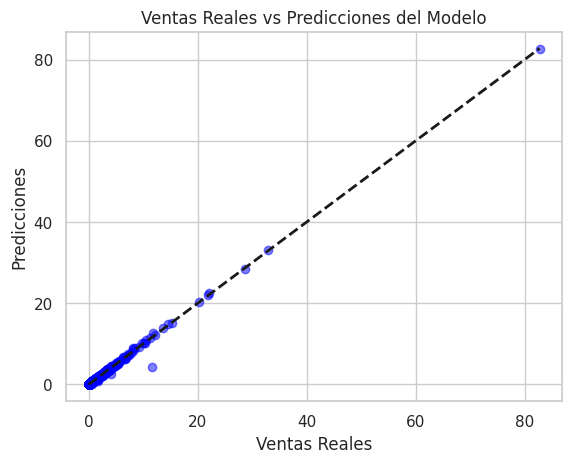

In [ ]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Ventas Reales')
plt.ylabel('Predicciones')
plt.title('Ventas Reales vs Predicciones del Modelo')
plt.show()

#Modelo 2: Predicción Basada en Factores de Mercado

In [ ]:
#Cargamos el dataset ya limpio
df_vgsales = pd.read_csv("https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_clean.csv")

#Mini limpieza para los valores nulos o infinitos de la variable Year
df_vgsales= df.dropna(subset=['Year'])
df_vgsales = df[np.isfinite(df['Year'])]

#Convertimos Género a variables númericos (Dummies)
df_vgsales['Year']= df_vgsales['Year'].astype(int)
df_vgsales_ml = pd.get_dummies(df_vgsales, columns=['Genre'], drop_first=True)

In [ ]:
#Selección de variables
columnas_genero = [col for col in df_vgsales_ml.columns if col.startswith('Genre_')]
X = df_vgsales_ml[['Year'] + columnas_genero]

y = df_vgsales_ml['Global_Sales']

In [ ]:
#Division de datos
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2,random_state=42)
#Instanceamos y entreanmos el modelo
modelo_vgsales= LinearRegression()
modelo_vgsales.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Predicción y evaluación
y_pred=modelo_vgsales.predict(X_test)
print(f'MSE_Score: {mean_squared_error(y_test, y_pred):.3f}')
print(f'R2_score: {r2_score(y_test, y_pred):.3f}')

MSE_Score: 4.259
R2_score: 0.005


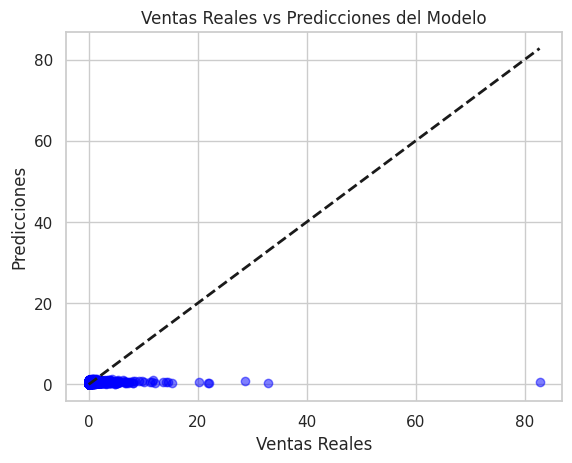

In [ ]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Ventas Reales')
plt.ylabel('Predicciones')
plt.title('Ventas Reales vs Predicciones del Modelo')
plt.show()

Aunque el $R^2$ es considerablemente más bajo, el modelo tiene un alto valor analítico.

Resultado: La baja precisión confirma que el éxito en la industria de los videojuegos es multifactorial, dependiendo de variables no presentes en el dataset como presupuestos de marketing, calidad crítica y competencia directa.Hallazgo: El modelo es honesto; prefiere una precisión baja pero real, a una precisión alta basada en información que no estaría disponible antes del lanzamiento de un título.

##Regresión Logística

#### Paso 1: Entorno de Trabajo y Carga de Datos


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Scikit-Learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             roc_curve, roc_auc_score, precision_recall_curve, auc)

# 1. Carga de datos
url = "https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_cat.csv"
df_RL = pd.read_csv(url)
df_RL.head()

# 2. Definición de la variable objetivo (y)
# Éxito = Ventas globales mayores a 1 millón
df['y'] = (df['Global_Sales'] > 1.0).astype(int)

#### Paso 2: Preprocesamiento y División Estratificada
Para evitar el Data Leakage, eliminamos cualquier información de ventas de nuestras variables predictoras. Solo usaremos


 su género y consola. Usamos stratify=y para mantener la proporción de "hits" en el entrenamiento y la prueba.

In [ ]:
# 1. Selección de variables (X) - Evitando fuga de datos
# Convertimos categorías a variables numéricas (Dummies)
X = pd.get_dummies(df[['Genre', 'Platform']], drop_first=True).astype(float)
y = df['y']

# 2. División del dataset (Train/Test Split)
# 70% para aprender, 30% para evaluar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Dimensiones: Entrenamiento {X_train.shape}, Prueba {X_test.shape}")

Dimensiones: Entrenamiento (11618, 41), Prueba (4980, 41)


#### Paso 3: Entrenamiento y Métricas de Matriz de Confusión
Entrenamos el modelo y evaluamos su desempeño binario. Aquí no solo importa el Accuracy (qué tanto le atina), sino el Recall (cuántos éxitos de la vida real fuimos capaces de capturar) y la Precision (qué tan confiable es el modelo cuando nos da una señal de éxito).

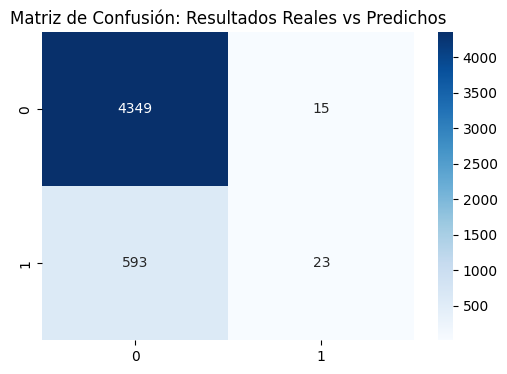

              precision    recall  f1-score   support

Ventas Bajas       0.88      1.00      0.93      4364
      Éxitos       0.61      0.04      0.07       616

    accuracy                           0.88      4980
   macro avg       0.74      0.52      0.50      4980
weighted avg       0.85      0.88      0.83      4980



In [ ]:
# 1. Instanciación y entrenamiento
modelo_ml = LogisticRegression(max_iter=10000)
modelo_ml.fit(X_train, y_train)

# 2. Predicciones
y_pred = modelo_ml.predict(X_test)

# 3. Visualización de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Resultados Reales vs Predichos')
plt.show()

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred, target_names=['Ventas Bajas', 'Éxitos']))

#### Paso 4: Análisis de Probabilidades y Curva ROC/AUC
La regresión logística estima una probabilidad. La Curva ROC evalúa qué tan bueno es el modelo separando las clases en todos los umbrales posibles. El AUC (Área bajo la curva) resume esto: entre más cerca esté de 1.0, mejor es el modelo "discriminando" entre un fracaso y un éxito.

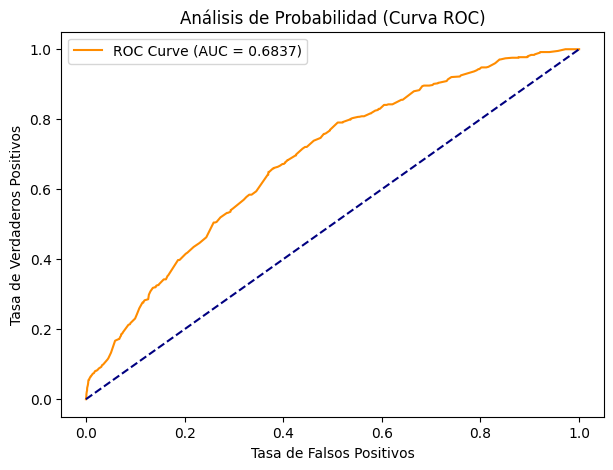

In [ ]:
# 1. Obtener probabilidades de la clase positiva (1)
y_probs = modelo_ml.predict_proba(X_test)[:, 1]

# 2. Cálculo de métricas ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 3. Graficar Curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Análisis de Probabilidad (Curva ROC)')
plt.legend()
plt.show()

#### Paso 5: Validación Cruzada y Ajuste de Hiperparámetro

Para asegurar que el modelo es robusto, usamos K-Fold Cross-Validation, probando el modelo en diferentes pedazos de los datos. Luego, usamos GridSearchCV para encontrar el mejor valor de $C$ (parámetro de regularización), que controla el equilibrio entre un modelo muy simple y uno demasiado complejo (overfitting).

In [ ]:
# 1. Validación Cruzada (5 iteraciones)
cv_scores = cross_val_score(modelo_ml, X, y, cv=5, scoring='f1')
print(f"F1-Score Promedio (Validación Cruzada): {cv_scores.mean():.4f}")

# 2. Búsqueda del mejor hiperparámetro (Tuning)
param_grid = {'C': [0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}
grid = GridSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print(f"Mejor parámetro 'C' encontrado: {grid.best_params_}")

F1-Score Promedio (Validación Cruzada): 0.0933
Mejor parámetro 'C' encontrado: {'C': 10, 'solver': 'liblinear'}


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Lista de umbrales que queremos probar
umbrales = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
reporte_umbrales = []

for t in umbrales:
    # Aplicar umbral
    y_pred_t = (y_probs >= t).astype(int)

    # Calcular métricas
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    accuracy = accuracy_score(y_test, y_pred_t)

    # Guardar en la lista
    reporte_umbrales.append({
        'Umbral': t,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Accuracy': accuracy
    })

# Crear DataFrame comparativo
df_comparativo = pd.DataFrame(reporte_umbrales)
print(df_comparativo)

   Umbral  Precision    Recall  F1-Score  Accuracy
0     0.1   0.180625  0.759740  0.291862  0.543976
1     0.2   0.249169  0.243506  0.246305  0.815663
2     0.3   0.481928  0.064935  0.114449  0.875703
3     0.4   0.603774  0.051948  0.095665  0.878514
4     0.5   0.605263  0.037338  0.070336  0.877912
5     0.6   0.645161  0.032468  0.061824  0.878112
6     0.7   0.666667  0.016234  0.031696  0.877309
7     0.8   0.600000  0.004870  0.009662  0.876506
8     0.9   0.000000  0.000000  0.000000  0.876305


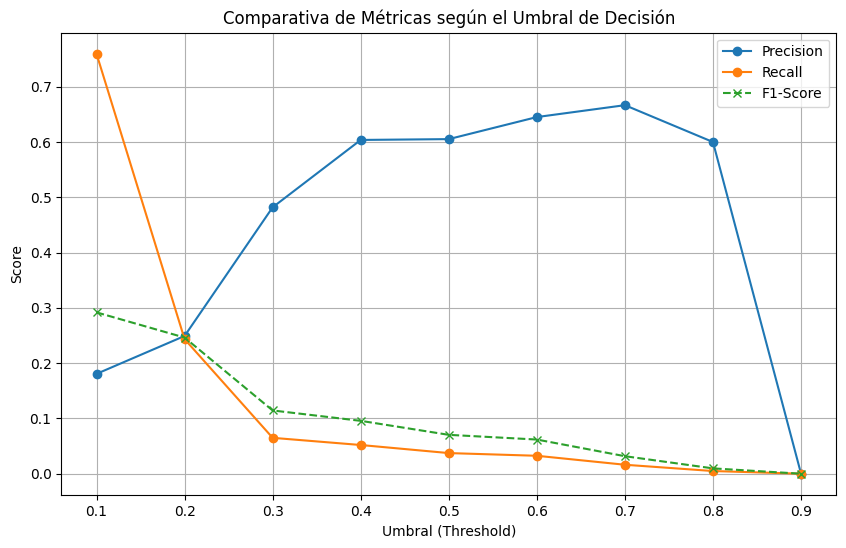

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_comparativo['Umbral'], df_comparativo['Precision'], label='Precision', marker='o')
plt.plot(df_comparativo['Umbral'], df_comparativo['Recall'], label='Recall', marker='o')
plt.plot(df_comparativo['Umbral'], df_comparativo['F1-Score'], label='F1-Score', marker='x', linestyle='--')
plt.title('Comparativa de Métricas según el Umbral de Decisión')
plt.xlabel('Umbral (Threshold)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, precision_score

# 1. Definimos los umbrales de ventas que queremos probar (millones)
umbrales_ventas = [0.5, 0.8, 1.0, 1.5, 2.0]
resultados_finales = []

for v_limit in umbrales_ventas:
    # Definir nueva variable objetivo según el umbral de ventas
    y_variable = (df['Global_Sales'] > v_limit).astype(int)

    # Dividir datos (usando el mismo X de siempre sin ventas regionales)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_variable, test_size=0.3, random_state=42, stratify=y_variable
    )

    # Entrenar modelo
    model = LogisticRegression(max_iter=10000).fit(X_train, y_train)

    # Obtener probabilidades
    probs = model.predict_proba(X_test)[:, 1]

    # Probamos con el umbral de probabilidad estándar (0.5)
    preds = (probs >= 0.5).astype(int)

    # Guardar métricas
    resultados_finales.append({
        'Ventas_Minimas_M': v_limit,
        'Num_Exitos_Total': y_variable.sum(),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds),
        'F1_Score': f1_score(y_test, preds)
    })

# Crear la tabla comparativa
df_sensibilidad = pd.DataFrame(resultados_finales)
print(df_sensibilidad)

   Ventas_Minimas_M  Num_Exitos_Total  Precision    Recall  F1_Score
0               0.5              3947   0.757576  0.042230  0.080000
1               0.8              2561   0.723404  0.044271  0.083436
2               1.0              2054   0.605263  0.037338  0.070336
3               1.5              1251   0.125000  0.002667  0.005222
4               2.0               846   0.000000  0.000000  0.000000


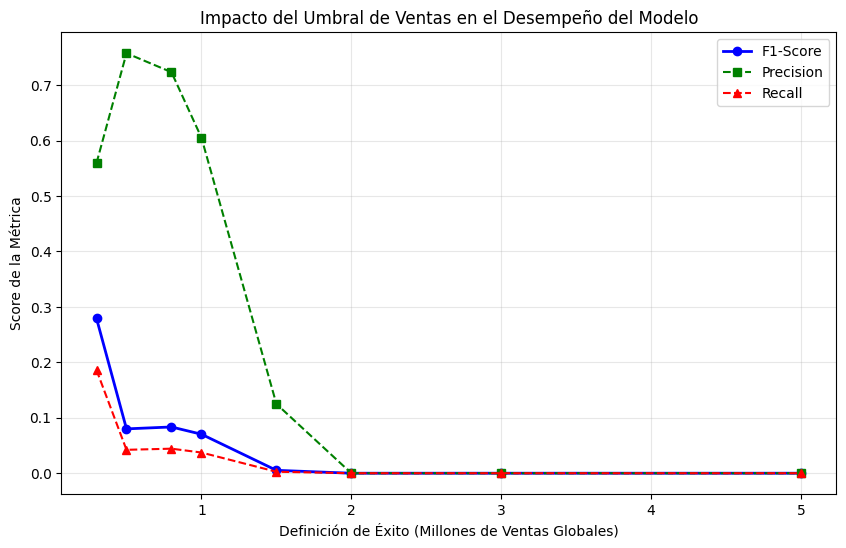

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Carga y preparación básica
url = "https://raw.githubusercontent.com/juanhuerta2114-png/Proyecto_final_3ersmestre_/refs/heads/main/data/vgsales_cat.csv"
df = pd.read_csv(url)
df['y'] = (df['Global_Sales'] > 1.0).astype(int)
X = pd.get_dummies(df[['Genre', 'Platform']], drop_first=True).astype(float)

# 2. Definimos los umbrales de ventas a evaluar (en millones)
umbrales_ventas = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0]
resultados = []

for v in umbrales_ventas:
    # Definimos la 'y' para este umbral específico
    y_v = (df['Global_Sales'] > v).astype(int)

    # Dividimos los datos (estratificado para manejar el desbalanceo)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_v, test_size=0.3, random_state=42, stratify=y_v
    )

    # Entrenamos el modelo
    model = LogisticRegression(max_iter=10000).fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Guardamos las métricas de la clase 'Éxito' (1)
    resultados.append({
        'Umbral_Ventas': v,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred)
    })

# 3. Convertir a DataFrame y Graficar
df_res = pd.DataFrame(resultados)

plt.figure(figsize=(10, 6))
plt.plot(df_res['Umbral_Ventas'], df_res['F1_Score'], marker='o', label='F1-Score', color='blue', linewidth=2)
plt.plot(df_res['Umbral_Ventas'], df_res['Precision'], marker='s', label='Precision', color='green', linestyle='--')
plt.plot(df_res['Umbral_Ventas'], df_res['Recall'], marker='^', label='Recall', color='red', linestyle='--')

plt.title('Impacto del Umbral de Ventas en el Desempeño del Modelo')
plt.xlabel('Definición de Éxito (Millones de Ventas Globales)')
plt.ylabel('Score de la Métrica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Árbol de Deciciones (Decision Tree)

### 1 Definición de Variables y Configuración del Experimento.



In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd

# 1. Seleccionamos las variables predictoras (X) eliminando 'Name' y el objetivo directo
columnas_interes = ['Genre', 'Platform', 'Year']
X = pd.get_dummies(df_AD[columnas_interes], drop_first=True).astype(float)

# 2. Definimos la lista de umbrales comerciales que vamos a evaluar
umbrales_ventas = [0.5, 0.75, 1.0]

# 3. Estructura para almacenar las métricas finales de cada experimento
historico_experimentos = {}

### 2 Preprocesamiento, Split y Tuning

In [ ]:
for umbral in umbrales_ventas:
    print(f" INICIANDO EXPERIMENTO: ÉXITO > {umbral} MILLONES DE COPIAS")

    # A. Re-etiquetado dinámico de la variable objetivo (y)
    y_dinamica = (df_AD['Global_Sales'] > umbral).astype(int)
    conteo = y_dinamica.value_counts()
    print(f"[Info] Distribución de Clases -> Fracasos (0): {conteo[0]} | Éxitos (1): {conteo[1]}")

    # B. División de datos con Estratificación adaptada al nuevo umbral
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
        X, y_dinamica, test_size=0.3, random_state=42, stratify=y_dinamica
    )

    # C. Definición de la rejilla de parámetros para la búsqueda
    param_grid = {
        'criterion': ['entropy', 'gini'],
        'max_depth': [3, 5, 7, 10],
        'min_samples_leaf': [5, 10, 20],
        'class_weight': ['balanced', None]
    }

    # D. Configuración e inicio de GridSearchCV con Validación Cruzada (K-Fold = 5)
    grid_search = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    # E. Entrenamiento de los múltiples árboles en paralelo
    grid_search.fit(X_train_d, y_train_d)

    # F. Evaluación del Árbol Ganador con el conjunto de prueba (X_test_d)
    mejor_arbol = grid_search.best_estimator_
    y_pred_d = mejor_arbol.predict(X_test_d)

    # G. Guardado de métricas en el histórico
    historico_experimentos[umbral] = {
        'Mejores Parámetros': str(grid_search.best_params_),
        'Accuracy': accuracy_score(y_test_d, y_pred_d),
        'F1-Score (Éxito)': f1_score(y_test_d, y_pred_d),
        'Modelo Objeto': mejor_arbol,
        'Datos_Prueba': (X_test_d, y_test_d, y_pred_d)
    }

    # Imprimir diagnóstico inmediato en pantalla
    print(f"\n-> Ganador para umbral {umbral}: {grid_search.best_params_}")
    print("\nReporte de Clasificación en Test:")
    print(classification_report(y_test_d, y_pred_d))

 INICIANDO EXPERIMENTO: ÉXITO > 0.5 MILLONES DE COPIAS
[Info] Distribución de Clases -> Fracasos (0): 12651 | Éxitos (1): 3947

-> Ganador para umbral 0.5: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 20}

Reporte de Clasificación en Test:
              precision    recall  f1-score   support

           0       0.85      0.65      0.73      3796
           1       0.35      0.62      0.45      1184

    accuracy                           0.64      4980
   macro avg       0.60      0.63      0.59      4980
weighted avg       0.73      0.64      0.67      4980

 INICIANDO EXPERIMENTO: ÉXITO > 0.75 MILLONES DE COPIAS
[Info] Distribución de Clases -> Fracasos (0): 13869 | Éxitos (1): 2729

-> Ganador para umbral 0.75: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5}

Reporte de Clasificación en Test:
              precision    recall  f1-score   support

           0       0.92      0.47      0.62      4

### 3 Tabla comparativa

In [ ]:
df_resultados = pd.DataFrame(historico_experimentos).T

print("--- RESUMEN DE COMPORTAMIENTO DEL MODELO POR UMBRAL ---")
# Verificar si df_resultados no está vacío antes de intentar acceder a las columnas
if not df_resultados.empty:
    display(df_resultados[['Mejores Parámetros', 'Accuracy', 'F1-Score (Éxito)']])
else:
    print("El DataFrame de resultados está vacío. Asegúrate de que 'historico_experimentos' se haya llenado correctamente.")
    print("Contenido de historico_experimentos:")
    display(historico_experimentos)

--- RESUMEN DE COMPORTAMIENTO DEL MODELO POR UMBRAL ---


,Mejores Parámetros,Accuracy,F1-Score (Éxito)
0.50,"{'class_weight': 'balanced', 'criterion': 'gin...",0.641968,0.451216
0.75,"{'class_weight': 'balanced', 'criterion': 'ent...",0.524498,0.350521
1.00,"{'class_weight': 'balanced', 'criterion': 'ent...",0.473896,0.285714


### 4 Mejor Modelo

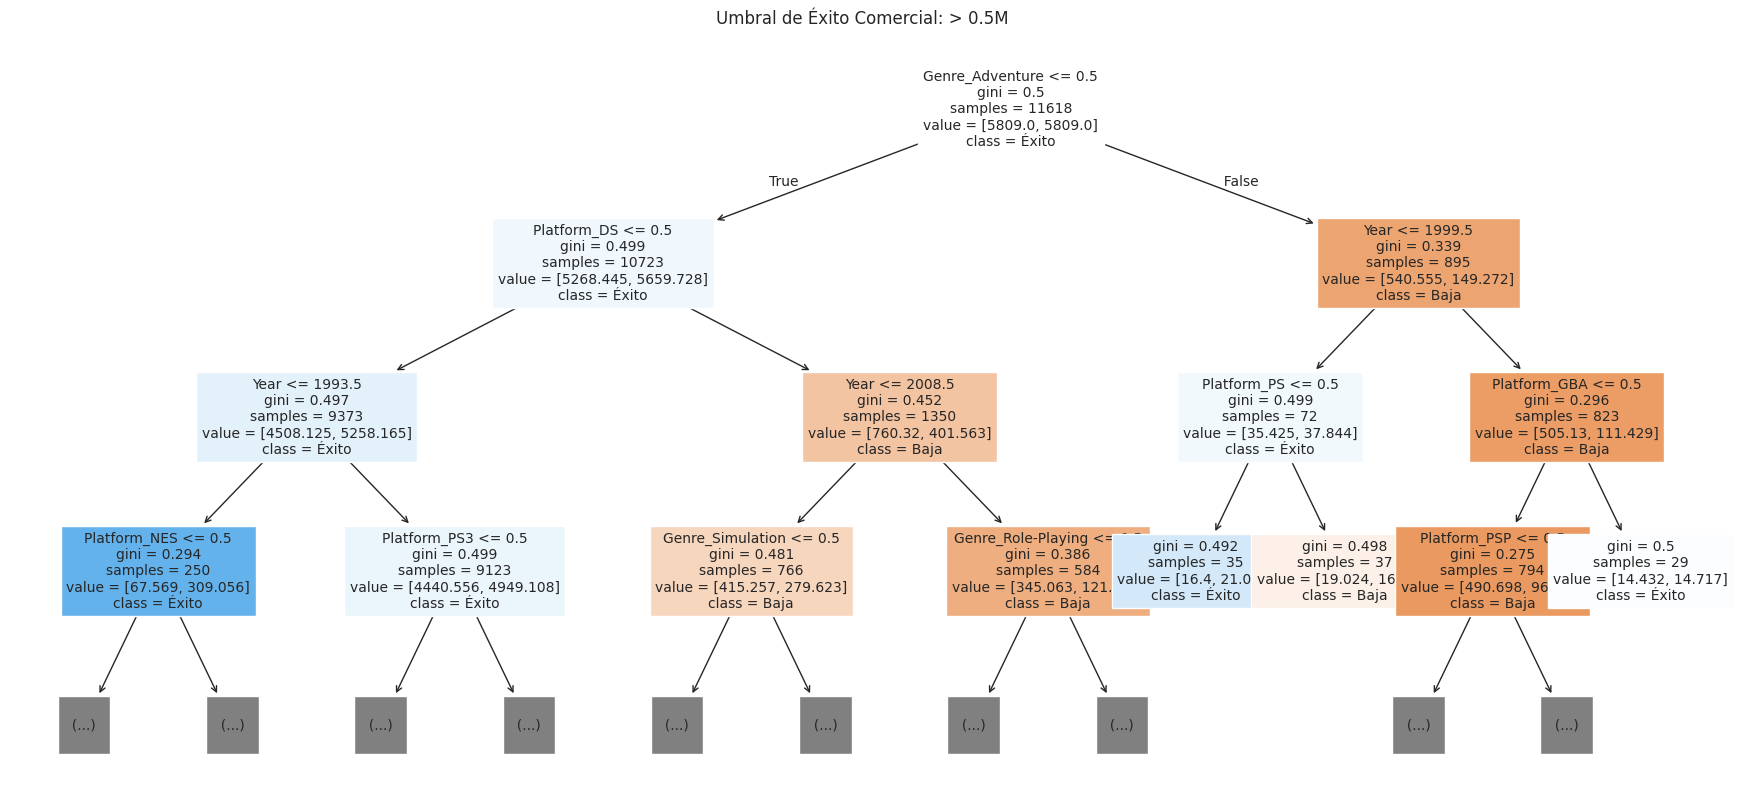

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

umbral_interes = 0.5
modelo_a_graficar = historico_experimentos[umbral_interes]['Modelo Objeto']

plt.figure(figsize=(22, 10))
plot_tree(
    modelo_a_graficar,
    feature_names=X.columns,
    class_names=['Baja', 'Éxito'],
    filled=True,
    fontsize=10,
    max_depth=3
)

plt.title(f"Umbral de Éxito Comercial: > {umbral_interes}M")
plt.show()

### 5 Grafica curvas ROC

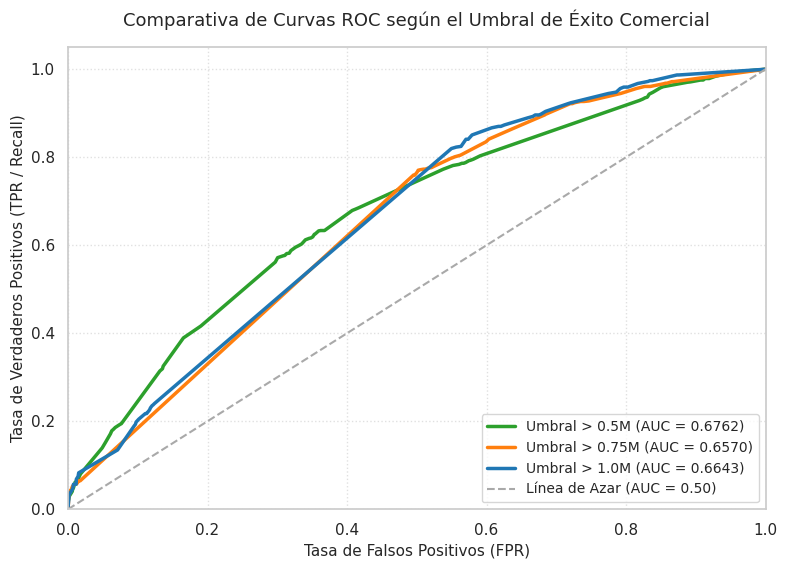

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

colores = {0.5: '#2ca02c', 0.75: '#ff7f0e', 1.0: '#1f77b4'}

for umbral, datos in historico_experimentos.items():
    modelo = datos['Modelo Objeto']
    X_test_d, y_test_d, _ = datos['Datos_Prueba']

    # Re-calculamos probabilidades para el gráfico
    y_prob = modelo.predict_proba(X_test_d)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_d, y_prob)
    auc_score = roc_auc_score(y_test_d, y_prob)

    # Pintamos la línea de cada modelo
    plt.plot(
        fpr, tpr,
        color=colores[umbral], lw=2.5,
        label=f'Umbral > {umbral}M (AUC = {auc_score:.4f})'
    )

# Dibujamos la diagonal de referencia (modelo inútil / azar puro)
plt.plot([0, 1], [0, 1], color='darkgrey', linestyle='--', lw=1.5, label='Línea de Azar (AUC = 0.50)')

# Ajustes estéticos de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=11)
plt.title('Comparativa de Curvas ROC según el Umbral de Éxito Comercial', fontsize=13, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### 6 Conclusion
En el uso del modelo de Machine Learning Arbol de Decision ademas de usar varios umbrales para determinar si un juego iba a ser un exito entre ellos el numero de ventas que va de 0.5, 0.75 a 1.0 millon de copias vendidas esto ayudo que dependiendo de la empresa, presupuesto y tipo de juego pues un juego sea considerado un exito y esto es variable para cada empresa. Ademas con el GridSearchCV, obligamos al metodo combinar y evaluar diferentes combinanciones entre ellas **"class_wight"** ('balanced','None') que le dice al modelo que penalice con mas fuerza los errores en la case de éxitos comerciales, **criterion** ('gini','entropy') las metricas para evaluar la pureza de los nodos y el modelo eligio el mejor segun el umbral de ventas para ser considerado un exito de ventas, **max_depth** (3,5,7,10) para controlar que tan complejas y especificas se volvian las reglas, **min_samples_leaf** (5, 10, 20) que indica el minimo de videojuegos que debe de haber en el ultimo nivel de juegos exitosos y evitar sobreajuste.

Y con estos cambios en el modelo evaluamos el desempeño para obtener el "mejor arbol de decisión" tomando encuenta "Accuracy", "Precision", "Recall", "F1-score" el mejor modelo el de el umbral con **0.5** millones de copias vendidas Ya que este modelo tiene el **F1-Score** de 0.45 un **recall** de **62%** y un **AUC** de **0.6762** que de los tres umbrales de ventas es el mas alto.

El AUC no es el mas alto esto no hace llegar a la conclusion que este modelo no es el mejor para este tipo de problemas para solucionarlo es tomar otro modelo de Machine Learning o añadir mas datos para ver si AUC aumenta.

## Random Forest

### Preparación de las variables (Random Forest)

In [ ]:
# Feature matrix (X), target (y)
X = df_clean.drop(columns=['Ventas_Cat'])
y = df_clean['Ventas_Cat']

In [ ]:
# División de datos de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Entrenamiento (Random Forest)

In [ ]:
# Entrenamiento del modelo
modelo_rf = RandomForestClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=5, n_estimators=33)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=20,
                       n_estimators=33)

### Métricas (Random Forest)

In [ ]:
# Predicciones
y_pred_train = modelo_rf.predict(X_train)
y_pred_test = modelo_rf.predict(X_test)

# Métricas
print("Métricas de Random Forest:\n")
acc_train = accuracy_score(y_pred=y_pred_train, y_true=y_train)
acc_test = accuracy_score(y_pred=y_pred_test, y_true=y_test)

pr_train = precision_score(y_pred=y_pred_train, y_true=y_train, average='weighted')
pr_test = precision_score(y_pred=y_pred_test, y_true=y_test, average='weighted')

rec_train = recall_score(y_pred=y_pred_train, y_true=y_train, average='weighted')
rec_test = recall_score(y_pred=y_pred_test, y_true=y_test, average='weighted')

f1_train = f1_score(y_pred=y_pred_train, y_true=y_train, average='weighted')
f1_test = f1_score(y_pred=y_pred_test, y_true=y_test, average='weighted')

print(f"Accuracy train: {acc_train:.4f}")
print(f"Accuracy test: {acc_test:.4f}\n")
print(f"Precision train: {pr_train:.4f}")
print(f"Precision test: {pr_test:.4f}\n")
print(f"Recall train: {rec_train:.4f}")
print(f"Recall test: {rec_test:.4f}\n")
print(f"F1 train: {f1_train:.4f}")
print(f"F1 test: {f1_test:.4f}\n")

Métricas de Random Forest:

Accuracy train: 0.7598
Accuracy test: 0.7617

Precision train: 0.6970
Precision test: 0.6818

Recall train: 0.7598
Recall test: 0.7617

F1 train: 0.6588
F1 test: 0.6611



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# K-Nearest Neighbors (KNN)

Entrenamiento (KNN)

In [ ]:
modelo_knn = KNeighborsClassifier(n_neighbors=20)
modelo_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=20)

Predicciones (KNN)

In [ ]:
y_pred_train = modelo_knn.predict(X_train)
y_pred_test  = modelo_knn.predict(X_test)

Métricas (KNN)

In [ ]:
print("Métricas de KNN:\n")

acc_train = accuracy_score(y_true=y_train, y_pred=y_pred_train)
acc_test  = accuracy_score(y_true=y_test,  y_pred=y_pred_test)

pr_train  = precision_score(y_true=y_train, y_pred=y_pred_train, average='weighted', zero_division=0)
pr_test   = precision_score(y_true=y_test,  y_pred=y_pred_test,  average='weighted', zero_division=0)

rec_train = recall_score(y_true=y_train, y_pred=y_pred_train, average='weighted')
rec_test  = recall_score(y_true=y_test,  y_pred=y_pred_test,  average='weighted')

f1_train  = f1_score(y_true=y_train, y_pred=y_pred_train, average='weighted')
f1_test   = f1_score(y_true=y_test,  y_pred=y_pred_test,  average='weighted')

print(f"Accuracy   train: {acc_train:.4f}    test: {acc_test:.4f}")
print(f"Precision  train: {pr_train:.4f}    test: {pr_test:.4f}")
print(f"Recall     train: {rec_train:.4f}    test: {rec_test:.4f}")
print(f"F1         train: {f1_train:.4f}    test: {f1_test:.4f}")

Métricas de KNN:

Accuracy   train: 0.7785    test: 0.7660
Precision  train: 0.7381    test: 0.7113
Recall     train: 0.7785    test: 0.7660
F1         train: 0.7159    test: 0.7043


# Complejidad Computacional 2026A: Proyecto Integrador



*   En jupyter notebook, los programas correspondientes de KNN y regresion logıstica hechos a mano, sin consulta de IA. Snippets tomados de la red deberan ir debidamente referenciados.
*   Medicion de tiempos de ejecucion de los algoritmos desarrollados usando la base de datos usada para el proyecto integrador general.
*   Calculo exacto de tiempo asintotico de ejecucion para cada algoritmo. Si se toma de alguna fuente, se debe de referenciar. Si no existe, se debe de ajustar en base a los resultados emp ́ıricos obtenidos.
*   Medicion de tiempos de ejecucion de los algoritmos propuestos (KNN y regresion logısitica) usando alguna librerıa de codigo abierto de python. Citar la paqueterıa de manera correcta en el reporte. Ajustar los resultados obtenidos al tiempo de ejecućon asintotico que reporta la paqueterıa.
*   Indicar cual fue la o las optimizaciones que usa la paqueterıa para implementar cad algoritmo, y como eso impacta en el escalamiento asintotico de ejecucion.



#KNN A MANO

In [ ]:
def distancia_euclidiana(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))  # ← fix bug 1

def knn_a_mano(X_train, y_train, X_test, k=5):
    predicciones = []
    for x_nuevo in X_test:
        distancias = []
        for i in range(len(X_train)):
            dist = distancia_euclidiana(X_train[i], x_nuevo)
            distancias.append((dist, y_train[i]))
        # ← fix bug 2: estas líneas van fuera del for interno
        distancias.sort(key=lambda x: x[0])  # menor a mayor
        vecinos_cercanos = distancias[:k]
        promedio_ventas = np.mean([v[1] for v in vecinos_cercanos])
        predicciones.append(promedio_ventas)
    return np.array(predicciones)

#Medición de tiempos

In [ ]:

MUESTRA_TRAIN = 3000
MUESTRA_TEST = 200

# Convertimos las variable a arreglos numéricos puros de NumPy
X_train_np = np.array(X_train[:MUESTRA_TRAIN])
y_train_np = np.array(y_train[:MUESTRA_TRAIN])
X_test_np = np.array(X_test[:MUESTRA_TEST])
y_test_np = np.array(y_test[:MUESTRA_TEST])



# 1. Medición del KNN Hecho a Mano
start_mano = time.time()
preds_mano = knn_a_mano(X_train_np, y_train_np, X_test_np, k=5)
end_mano = time.time()
tiempo_mano = end_mano - start_mano

knn_sklearn = KNeighborsRegressor(n_neighbors=5, algorithm='brute')
# 4. EJECUCIÓN Y MEDICIÓN CON SCIKIT-LEARN
start_sk = time.time()
knn_sklearn.fit(X_train_np, y_train_np)
preds_sk = knn_sklearn.predict(X_test_np)
end_sk = time.time()
tiempo_sk = end_sk - start_sk


print(f"==================================================")
print(f"TIEMPOS EMPÍRICOS OBTENIDOS:")
print(f"⏱️ Tiempo KNN hecho a mano:  {tiempo_mano:.6f} segundos")
print(f"⏱️ Tiempo KNN Scikit-Learn:  {tiempo_sk:.6f} segundos")
print(f"Diferencia de velocidad: {tiempo_mano / tiempo_sk:.2f}x veces más rápido la librería.")

TIEMPOS EMPÍRICOS OBTENIDOS:
⏱️ Tiempo KNN hecho a mano:  4.638363 segundos
⏱️ Tiempo KNN Scikit-Learn:  0.005220 segundos
Diferencia de velocidad: 888.63x veces más rápido la librería.


## Gráfica de tiempos de ejecución

###Preparación de las muestras, experimentación y recolección de tiempos

In [ ]:
#1
# Fijamos la muestra de entrenamiento para que la comparación sea justa
MUESTRA_TRAIN = 3000
X_train_np = np.array(X_train[:MUESTRA_TRAIN])
y_train_np = np.array(y_train[:MUESTRA_TRAIN])

# Definimos diferentes tamaños de datos de prueba para ver la curva de crecimiento
tamanos_test = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]

# Listas vacías donde guardaremos los tiempos obtenidos
tiempos_mano = []
tiempos_sklearn = []


#2
print("Iniciando benchmark de tiempos...")

for n_test in tamanos_test:
    # Recortamos la muestra de prueba al tamaño actual del ciclo
    X_test_np = np.array(X_test[:n_test])

    # --- Medición: KNN Hecho a Mano ---
    start_mano = time.time()
    _ = knn_a_mano(X_train_np, y_train_np, X_test_np, k=5)
    end_mano = time.time()
    tiempos_mano.append(end_mano - start_mano)

    # --- Medición: KNN Scikit-Learn ---
    knn_sklearn = KNeighborsRegressor(n_neighbors=5, algorithm='brute')
    start_sk = time.time()
    knn_sklearn.fit(X_train_np, y_train_np)
    _ = knn_sklearn.predict(X_test_np)
    end_sk = time.time()
    tiempos_sklearn.append(end_sk - start_sk)

    print(f"Completado tamaño de prueba n = {n_test} | Mano: {tiempos_mano[-1]:.4f}s | Sklearn: {tiempos_sklearn[-1]:.4f}s")

print("¡Benchmark terminado con éxito!")

Iniciando benchmark de tiempos...
Completado tamaño de prueba n = 20 | Mano: 0.3516s | Sklearn: 0.0021s
Completado tamaño de prueba n = 40 | Mano: 0.7622s | Sklearn: 0.0033s
Completado tamaño de prueba n = 60 | Mano: 1.7052s | Sklearn: 0.0037s
Completado tamaño de prueba n = 80 | Mano: 1.6184s | Sklearn: 0.0030s
Completado tamaño de prueba n = 100 | Mano: 1.7584s | Sklearn: 0.0048s
Completado tamaño de prueba n = 120 | Mano: 2.0588s | Sklearn: 0.0038s
Completado tamaño de prueba n = 140 | Mano: 3.6906s | Sklearn: 0.0040s
Completado tamaño de prueba n = 160 | Mano: 3.5670s | Sklearn: 0.0082s
Completado tamaño de prueba n = 180 | Mano: 4.0965s | Sklearn: 0.0046s
Completado tamaño de prueba n = 200 | Mano: 3.5789s | Sklearn: 0.0058s
¡Benchmark terminado con éxito!


### Gráfica

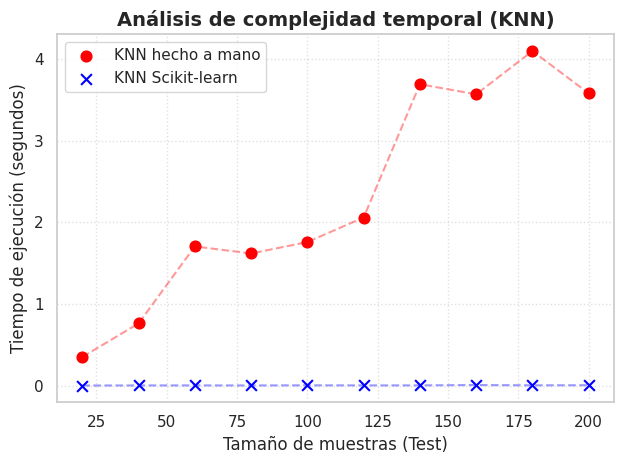

In [ ]:
#3
# Creamos los puntos de dispersión usando scatter
plt.scatter(tamanos_test, tiempos_mano, color='red', label='KNN hecho a mano', marker='o', s=60)
plt.scatter(tamanos_test, tiempos_sklearn, color='blue', label='KNN Scikit-learn', marker='x', s=60)

# Añadimos una línea punteada ligera para ayudar a visualizar la tendencia
plt.plot(tamanos_test, tiempos_mano, color='red', linestyle='--', alpha=0.4)
plt.plot(tamanos_test, tiempos_sklearn, color='blue', linestyle='--', alpha=0.4)

# Formato formal y etiquetas
plt.title('Análisis de complejidad temporal (KNN)', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de muestras (Test)', fontsize=12)
plt.ylabel('Tiempo de ejecución (segundos)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Ajuste automático de márgenes para que no se corten los textos al guardar
plt.tight_layout()

# Mostrar y guardar gráfico en Colab
plt.savefig('comparativa_complejidad_knn.svg', format='svg', bbox_inches='tight')
plt.show()

## Regresion Logistica


Antes de decidir si algo es clase 0 o clase 1, la regresión logística calcula una puntuación basada en los pesos y las características del dato. Matemáticamente es el producto punto de dos vectores:

1. combinacion lineal (pre-activacion)
Es la suma ponderada de las caracteristicas de la muestra multiplicadas por sus respectivos pesos.
$$z = w_0x_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n = \sum_{j=0}^{n} w_j x_j$$



```
for i in range(len(vector_x)):
    total += vector_x[i] * vector_w[i]
```



En su forma vectorial compacta:
$$z = \mathbf{w}^T \mathbf{x}$$

2. La funcion de Activación (Sigmoide)
 math.exp(-z)
 $$h_\mathbf{w}(\mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$



```
return 1 / (1 + math.exp(-z))
```



3. Función de Costo (Entropia Cruzada Binaria)
Funcion que se busca minimizar durante el entrenamiento para un conjunto de m muestras
$$J(\mathbf{w}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h_\mathbf{w}(\mathbf{x}^{(i)})) + (1 - y^{(i)}) \log(1 - h_\mathbf{w}(\mathbf{x}^{(i)})) \right]$$

4. Cálculo del Gradiente (Derivadas Parciales)
La derivada parcial de la función de costo con respecto a cada peso individual wj.
$$\frac{\partial J(\mathbf{w})}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\mathbf{w}(\mathbf{x}^{(i)}) - y^{(i)} \right) x_j^{(i)}$$



```
for i in range(num_muestras):
    # ... calcula error ...
    for j in range(num_caracteristicas):
        gradientes[j] += error * xi[j] # Sumatoria manual elemento por elemento
```




5. Gradiente Descendiente
Ecuación que modifica los pesos en cada época del entrenamiento. donde $$\alpha$$ representa la tasa de aprendizaje.
$$w_j := w_j - \alpha \frac{\partial J(\mathbf{w})}{\partial w_j}$$

si se sustituye el grandiente directamente en la regla de actualización para tener la ecuación completa en un solo bloque:
$$w_j := w_j - \frac{\alpha}{m} \sum_{i=1}^{m} \left( h_\mathbf{w}(\mathbf{x}^{(i)}) - y^{(i)} \right) x_j^{(i)}$$



```
for j in range(num_caracteristicas):
    pesos[j] = pesos[j] - (alpha * (gradientes[j] / num_muestras))
```




In [ ]:
import math

def funcion_sigmoide(z):
    """Calcula la función sigmoide de forma escalar."""
    return 1 / (1 + math.exp(-z))

def producto_punto_manual(vector_x, vector_w):
    """Calcula el producto punto entre dos listas usando un ciclo for."""
    total = 0.0
    for i in range(len(vector_x)):
        total += vector_x[i] * vector_w[i]
    return total

In [ ]:
def entrenar_regresion_logistica(X, y, alpha, epocas):
    """
    Entrena el modelo usando ciclos for explícitos.
    X: Lista de listas (matriz de características)
    y: Lista de etiquetas (0 o 1)
    alpha: Tasa de aprendizaje (learning rate)
    epocas: Número de iteraciones completas sobre el dataset
    """
    num_muestras = len(X)
    num_caracteristicas = len(X[0])

    # Inicializamos los pesos en cero de forma manual
    pesos = [0.0] * num_caracteristicas

    # Ciclo 1: Épocas
    for epoca in range(epocas):
        # Lista para acumular los gradientes de esta época
        gradientes = [0.0] * num_caracteristicas

        # Ciclo 2: Muestras (m)
        for i in range(num_muestras):
            xi = X[i]
            yi = y[i]

            # Calcular la predicción para la muestra i
            z = producto_punto_manual(xi, pesos)
            prediccion = funcion_sigmoide(z)
            error = prediccion - yi

            # Ciclo 3: Características (n) - Acumular gradiente
            for j in range(num_caracteristicas):
                gradientes[j] += error * xi[j]

        # Actualización de pesos después de revisar todas las muestras
        for j in range(num_caracteristicas):
            pesos[j] = pesos[j] - (alpha * (gradientes[j] / num_muestras))

    return pesos

In [ ]:
def predecir_regresion_logistica(X, pesos):
    """Genera predicciones (0 o 1) para un conjunto de datos."""
    predicciones = []
    for i in range(len(X)):
        z = producto_punto_manual(X[i], pesos)
        probabilidad = funcion_sigmoide(z)

        # Umbral de decisión
        if probabilidad >= 0.5:
            predicciones.append(1)
        else:
            predicciones.append(0)
    return predicciones

In [ ]:
# Datos de entrenamiento manuales (4 muestras, 2 características)
# Nota: Añadimos un 1 al principio de cada muestra para que actúe como el 'bias' (intersección)
X_entrenamiento = [
    [1.0, 0.5, 1.2],
    [1.0, 0.9, 1.8],
    [1.0, 4.5, 5.2],
    [1.0, 5.1, 6.0]
]
y_entrenamiento = [0, 0, 1, 1] # Dos clases bien definidas

# Hiperparámetros
tasa_aprendizaje = 0.1
iteraciones = 1000

# Ejecución del entrenamiento
pesos_finales = entrenar_regresion_logistica(X_entrenamiento, y_entrenamiento, tasa_aprendizaje, iteraciones)

print("Pesos optimizados manualmente:")
print(pesos_finales)

# Evaluación rápida
predicciones = predecir_regresion_logistica(X_entrenamiento, pesos_finales)
print("\nEtiquetas reales:     ", y_entrenamiento)
print("Predicciones del modelo:", predicciones)

Pesos optimizados manualmente:
[-4.231847567190623, 2.769802555203882, -0.7513236854635433]

Etiquetas reales:      [0, 0, 1, 1]
Predicciones del modelo: [0, 0, 1, 1]


In [ ]:
import numpy as np
import time
from sklearn.linear_model import LogisticRegression

# 1. Definición de los tamaños del dataset que vamos a evaluar (Eje X)
tamanos_dataset = [100, 1000, 5000, 10000, 15000, 20000]

# 2. Listas vacías para almacenar los tiempos calculados
tiempos_manual = []
tiempos_sklearn = []

# 3. Parámetros fijos del experimento
num_caracteristicas = 5
epocas = 50
tasa_aprendizaje = 0.01

In [ ]:
print("=== Iniciando Experimento de Tiempos de Ejecución ===")

for m in tamanos_dataset:
    # Generación de datos aleatorios controlados
    np.random.seed(42)
    X_np = np.random.randn(m, num_caracteristicas)

    # Preparar datos en listas nativas y añadir columna de 1s para el Bias manual
    X_manual = np.c_[np.ones(m), X_np].tolist()
    y_lista = np.random.randint(0, 2, m).tolist()
    y_np = np.array(y_lista)

    # Medición del Algoritmo Hecho a Mano
    inicio_manual = time.time()
    pesos_m = entrenar_regresion_logistica(X_manual, y_lista, tasa_aprendizaje, epocas)
    fin_manual = time.time()
    t_manual = fin_manual - inicio_manual
    tiempos_manual.append(t_manual)

    # Medición de Scikit-Learn
    modelo_sk = LogisticRegression(solver='lbfgs', max_iter=epocas)
    inicio_sk = time.time()
    modelo_sk.fit(X_np, y_np)
    fin_sk = time.time()
    t_sk = fin_sk - inicio_sk
    tiempos_sklearn.append(t_sk)

    # Mostrar el progreso en tiempo real
    print(f"Dataset m={m:<6} | Manual: {t_manual:.4f}s | Sklearn: {t_sk:.4f}s")

print("=== Experimento Terminado con Éxito ===")

=== Iniciando Experimento de Tiempos de Ejecución ===
Dataset m=100    | Manual: 0.0039s | Sklearn: 0.0026s
Dataset m=1000   | Manual: 0.0789s | Sklearn: 0.0023s
Dataset m=5000   | Manual: 0.2308s | Sklearn: 0.0033s
Dataset m=10000  | Manual: 0.4416s | Sklearn: 0.0039s
Dataset m=15000  | Manual: 0.6477s | Sklearn: 0.0054s
Dataset m=20000  | Manual: 0.8764s | Sklearn: 0.0052s
=== Experimento Terminado con Éxito ===


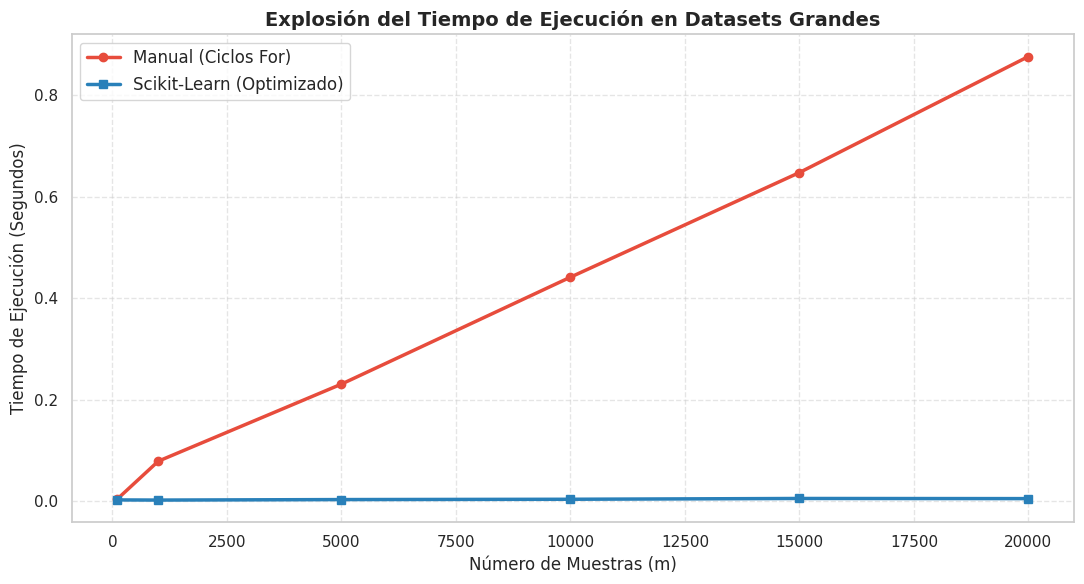

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

# Dibujar las curvas originales
plt.plot(tamanos_dataset, tiempos_manual, marker='o', color='#E74C3C', linewidth=2.5, label='Manual (Ciclos For)')
plt.plot(tamanos_dataset, tiempos_sklearn, marker='s', color='#2980B9', linewidth=2.5, label='Scikit-Learn (Optimizado)')

# --- TRUCO VISUAL: ESCALA LOGARÍTMICA (Opcional pero recomendado) ---
# Quita el símbolo '#' de la siguiente línea si quieres ver la diferencia en ÓRDENES DE MAGNITUD
# plt.yscale('log')

plt.title('Explosión del Tiempo de Ejecución en Datasets Grandes', fontsize=14, fontweight='bold')
plt.xlabel('Número de Muestras (m)', fontsize=12)
plt.ylabel('Tiempo de Ejecución (Segundos)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()